In [29]:
import os
import sys
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import re
import anndata as ad
import statistics
import torch
import scvi
import tempfile
import sklearn
import mudata as md
import muon as mu
md.set_options(pull_on_update=False)
import muon
from datetime import datetime
from scib_metrics.benchmark import Benchmarker
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from multiprocessing import Pool
import uuid
print("Last run with scvi-tools version:", scvi.__version__)
scvi.settings.num_threads = 48
scvi.settings.seed = 0
sc._settings.n_jobs=48
sc.settings.verbosity = 4
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='pdf')
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

Seed set to 0


Last run with scvi-tools version: 1.3.3


In [2]:
sc.logging.print_header()

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/session_info2/__init__.py:125: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  and (v := getattr(pkg, "__version__", None))


Package,Version
ipykernel,6.30.1
scipy,1.15.3
numpy,2.2.4
pandas,2.3.3
scanpy,1.11.4
seaborn,0.13.2
matplotlib,3.10.5
anndata,0.12.4
torch,2.8.0 (2.8.0+cu128)
scvi-tools,1.3.3


In [3]:
dataset='CEACAM8_Neg_Neutrophil_scVI'#cell type

In [4]:
obj_path = f'/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R3/{dataset}/'
sc.settings.figdir = obj_path

In [6]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_HVG.h5ad")

# 1. Load latent representation

In [7]:
adata.obsm["X_scVI"]=np.load(f"{obj_path}{dataset}_X_scVI.npy")

In [8]:
# sc.pp.neighbors take about 60 minutes for 3000M cells
print(f"Do sc.pp.neighbors with AnnoyTransformer,{datetime.now()}")
sc.pp.neighbors(adata, transformer=AnnoyTransformer(20), use_rep='X_scVI')

Do sc.pp.neighbors with AnnoyTransformer,2025-11-14 19:26:22.374780
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors


/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


    computed neighbors (0:30:08)
    computed connectivities (0:03:43)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:33:52)


In [ ]:
print(f"Run UMAP,{datetime.now()}")
sc.tl.umap(adata, min_dist=0.5)

Run UMAP,2025-11-14 20:00:15.565029
computing UMAP


  0%|          | 0/200 [00:00<?, ?it/s]

	completed  0  /  200 epochs
	completed  20  /  200 epochs


In [28]:
adata

AnnData object with n_obs × n_vars = 28400004 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score', 'scDblFinder.class', 'L4_leiden_TOTALVI_0.1', 'L4_leiden_TOTALVI_0.5', 'L4_leiden_TOTALVI_1', 'L4_leiden_TOTALVI_1.5', 'L4_leiden_TOTALVI_0.3', 'L4_leiden_TOTALVI_0.8', 'L4_leiden_scVI_0.1', 'L4_leiden_scVI_0.5', 'L4_leiden_scVI_1', 'L4_leiden_scVI_1.5', 'L4_leiden_scVI_0.3', 'L4_leiden_sc

In [25]:
def run_leiden_parallel(params):
    global adata
    key_added = f"L4_leiden_scVI_{params['resolution']}"
    sc.tl.leiden(adata, key_added=f'L4_leiden_scVI_{params['resolution']}', 
                 **params,
                 use_weights=True,directed=False,flavor="igraph",)
    return {key_added: adata.obs[key_added]}

In [26]:
param = [
        {"resolution": 0.1},
        {"resolution": 0.5},
        {"resolution": 1},
        {"resolution": 1.5},
        {"resolution": 0.3},
        {"resolution": 0.8},
]

In [ ]:
with Pool(6) as p:
    leiden_columns = p.map(run_leiden_parallel, param)

In [ ]:
for col_dict in leiden_columns:
    for key, values in col_dict.items():
        adata.obs[key] = values

In [ ]:
del adata.obsp
del adata.layers

In [ ]:
adata.write(f"{obj_path}{dataset}_HVG.h5ad",compression="gzip")

In [ ]:
leiden_data = adata.obs.loc[:,['L4_leiden_scVI_0.1','L4_leiden_scVI_0.5', 'L4_leiden_scVI_1', 'L4_leiden_scVI_1.5', 'L4_leiden_scVI_0.3','L4_leiden_scVI_0.8']]
obsm = adata.obsm
leiden_groups=['L4_leiden_scVI_0.1','L4_leiden_scVI_0.5', 'L4_leiden_scVI_1', 'L4_leiden_scVI_1.5', 'L4_leiden_scVI_0.3','L4_leiden_scVI_0.8']

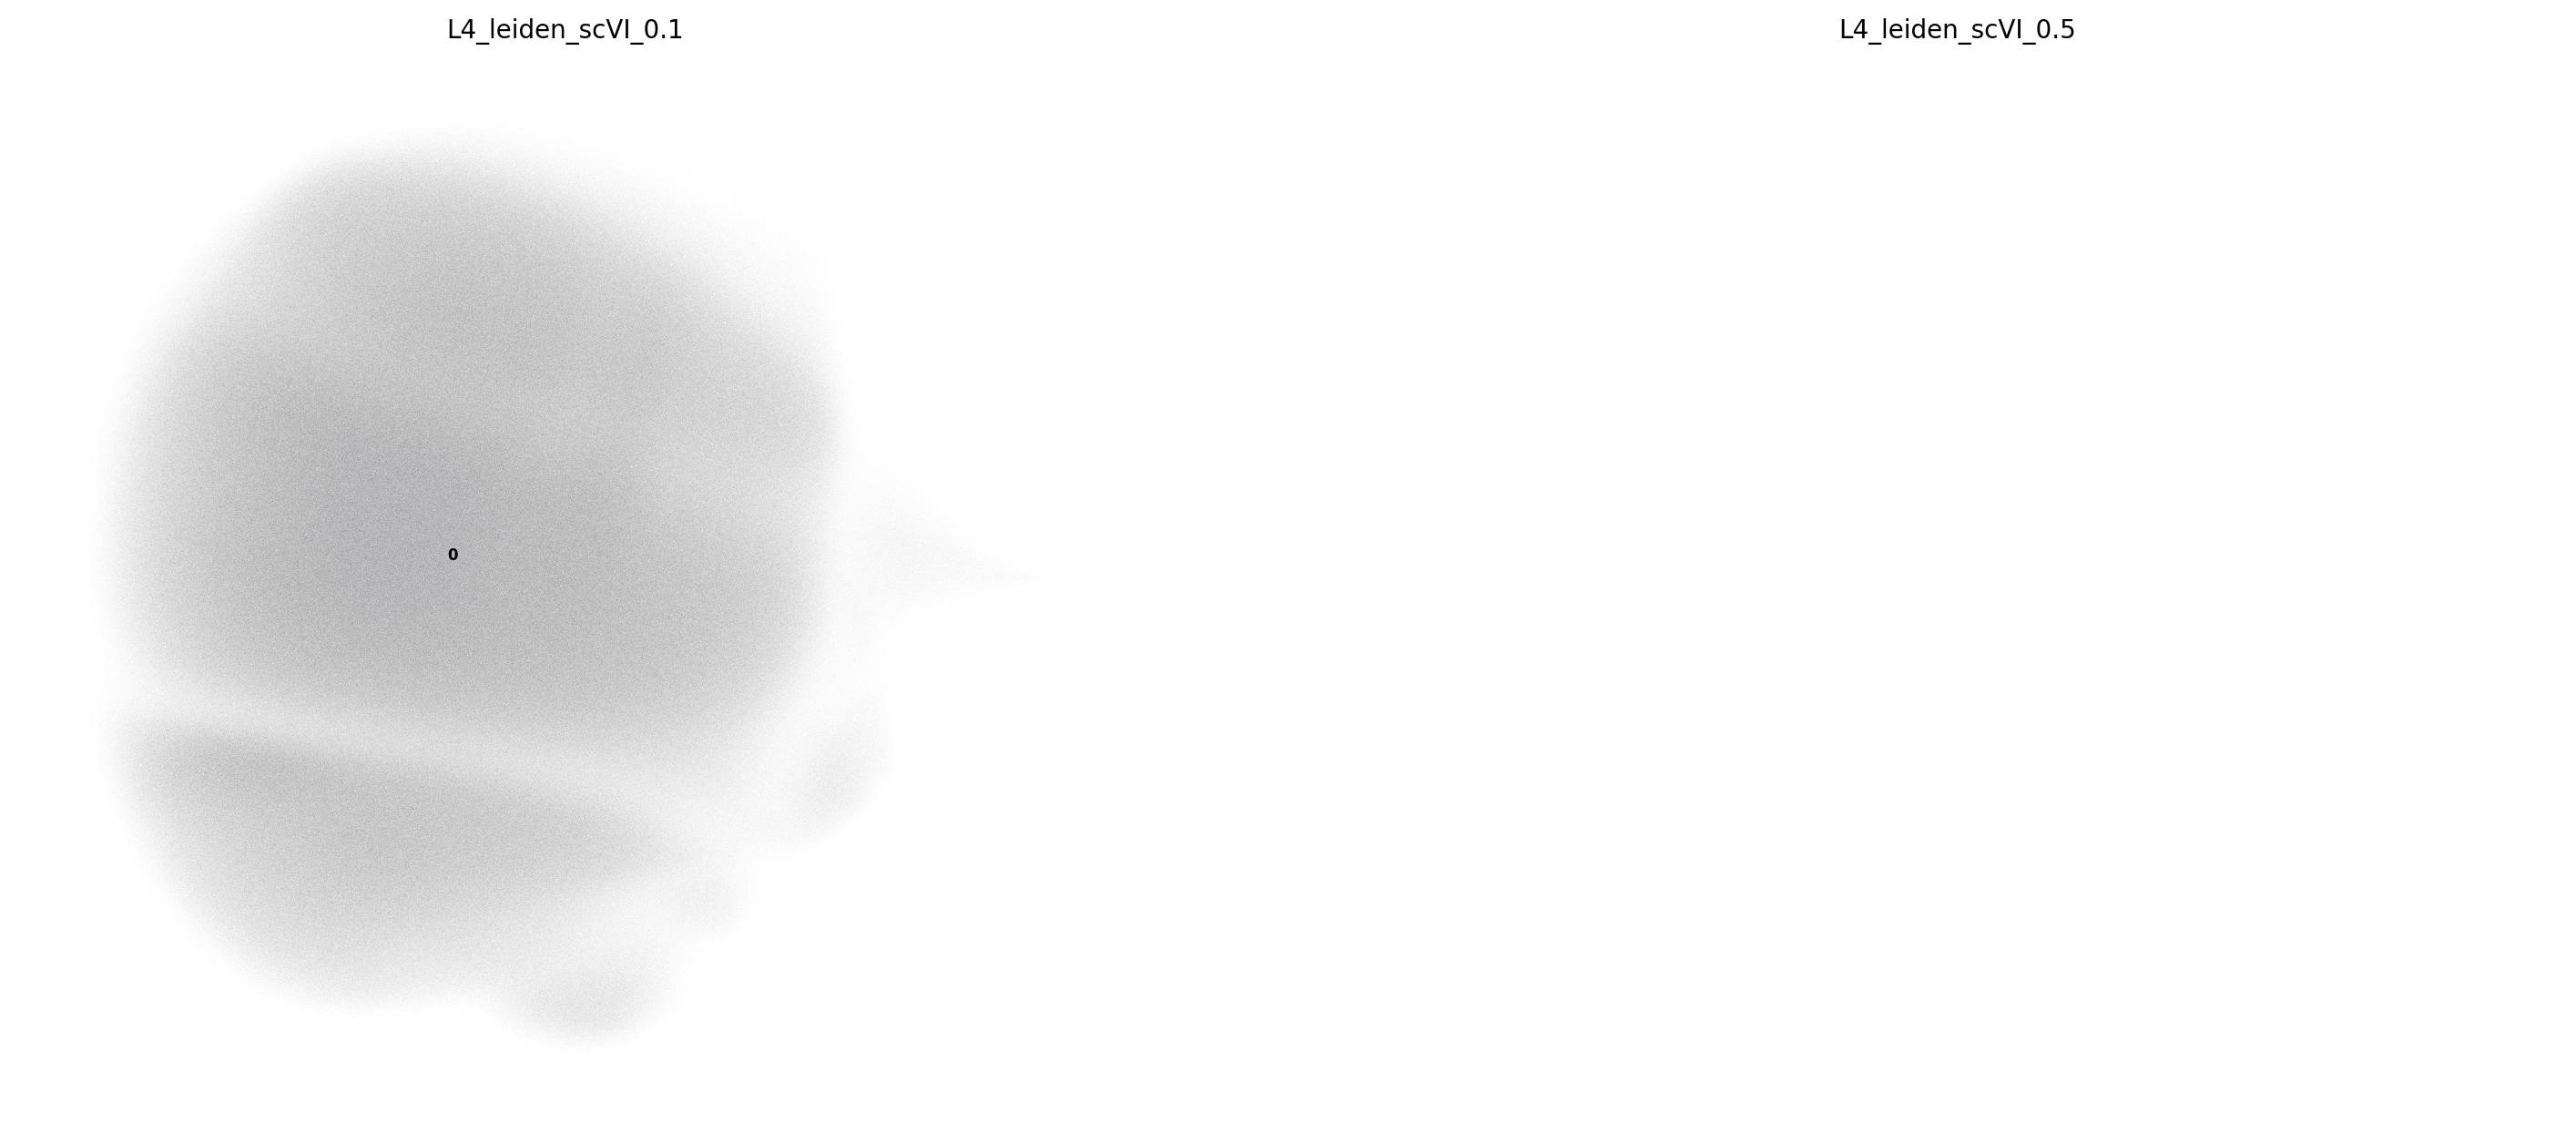

In [30]:
print(f"Plot umap,{datetime.now()}")
sc.pl.umap(
    adata,
    color=leiden_groups,
    legend_fontsize=6,legend_loc='on data',ncols=3,frameon=False,
    save=f'_{dataset}_scVI_L3_annoy_leiden',show=False
)

In [ ]:
sc.pl.umap(
    adata,
    color='L4_leiden_scVI_0.3',
    legend_fontsize=6,legend_loc='on data',ncols=3,frameon=False,
    save=f'_{dataset}_scVI_L3_annoy_leiden_0.3',show=False
)

In [ ]:
import session_info
session_info.show()